<a href="https://colab.research.google.com/github/marwaashfaq2004-ai/ANN-BLOOD-CELL-CLASSIFICATION-PROJECT/blob/main/ANN_PROJECT(AneRBC).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
#  Task 1 — Dataset Loading & Cleaning

In [3]:
# Task 1.1 — Install & Imports
!pip install -q seaborn
import os, zipfile, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
import torchvision.transforms as transforms
import torchvision.models as models
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_score, recall_score, f1_score
)
warnings.filterwarnings('ignore')
# Seed for reproducibility
SEED = 42
def set_seed(s=42):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic = True
set_seed()
DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CLASSES     = ['basophil','eosinophil','erythroblast','ig',
               'lymphocyte','monocyte','neutrophil','platelet']
NUM_CLASSES = len(CLASSES)
IMG_SIZE    = 224
BATCH_SIZE  = 32
MEAN        = [0.485, 0.456, 0.406]
STD         = [0.229, 0.224, 0.225]
print(f' Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f' GPU: {torch.cuda.get_device_name(0)}')
print(' All imports done!')


 Device: cuda
 GPU: Tesla T4
 All imports done!


Mount Google Drive & Extract Dataset

In [4]:
# Task 1.1 — Mount Google Drive & Extract Dataset
from google.colab import drive
drive.mount('/content/drive')
#   Change this path if your zip is in a subfolder
ZIP_PATH = '/content/drive/MyDrive/archive.zip'
RAW_DIR  = '/content/data/bloodcells_dataset'
DATA_DIR = '/content/data'
os.makedirs(DATA_DIR, exist_ok=True)
if not os.path.exists(RAW_DIR):
    print(' Extracting dataset...')
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(DATA_DIR)
    print(' Extraction done!')
else:
    print(' Dataset already extracted.')
for cls in CLASSES:
    n = len(list(Path(f'{RAW_DIR}/{cls}').glob('*.jpg')))
    print(f'  {cls:20s}: {n} images')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 Extracting dataset...
 Extraction done!
  basophil            : 1218 images
  eosinophil          : 3117 images
  erythroblast        : 1551 images
  ig                  : 2895 images
  lymphocyte          : 1214 images
  monocyte            : 1420 images
  neutrophil          : 3329 images
  platelet            : 2348 images


## Task 1.2 — Data Validation

 Total valid images : 17092
 Corrupted (removed): 0


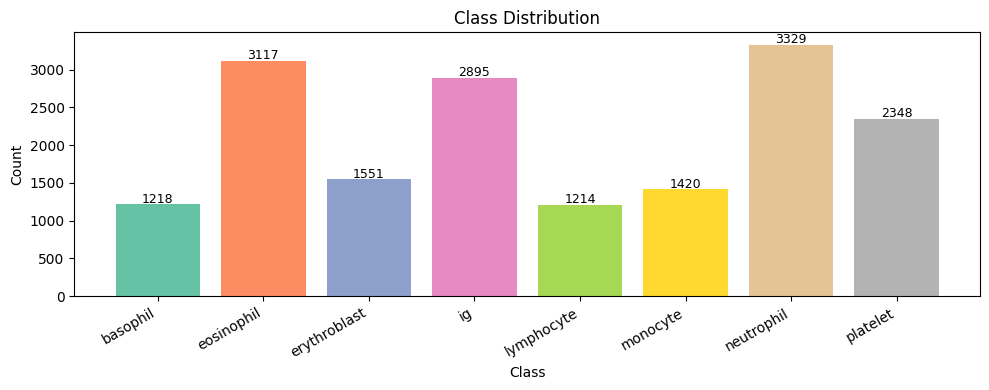

label
basophil        1218
eosinophil      3117
erythroblast    1551
ig              2895
lymphocyte      1214
monocyte        1420
neutrophil      3329
platelet        2348
Name: count, dtype: int64


In [5]:
# Task 1.2 — Check corrupted images + class distribution
records = []
bad     = []
for cls in CLASSES:
    for p in Path(f'{RAW_DIR}/{cls}').glob('*'):
        if p.suffix.lower() not in ('.jpg','.jpeg','.png'): continue
        try:
            with Image.open(p) as img: img.verify()
            records.append({'path': str(p), 'label': cls})
        except:
            bad.append(str(p))
print(f' Total valid images : {len(records)}')
print(f' Corrupted (removed): {len(bad)}')
for p in bad: os.remove(p)
df_all = pd.DataFrame(records)
# Class distribution bar chart
dist = df_all['label'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(10,4))
colors = plt.cm.Set2(np.linspace(0,1,len(dist)))
bars = ax.bar(dist.index, dist.values, color=colors)
for b,v in zip(bars, dist.values):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+20,
            str(v), ha='center', fontsize=9)
ax.set_title('Class Distribution'); ax.set_xlabel('Class')
ax.set_ylabel('Count')
plt.xticks(rotation=30, ha='right')
plt.tight_layout(); plt.show()
print(dist)


## Task 1.3 — Preprocessing

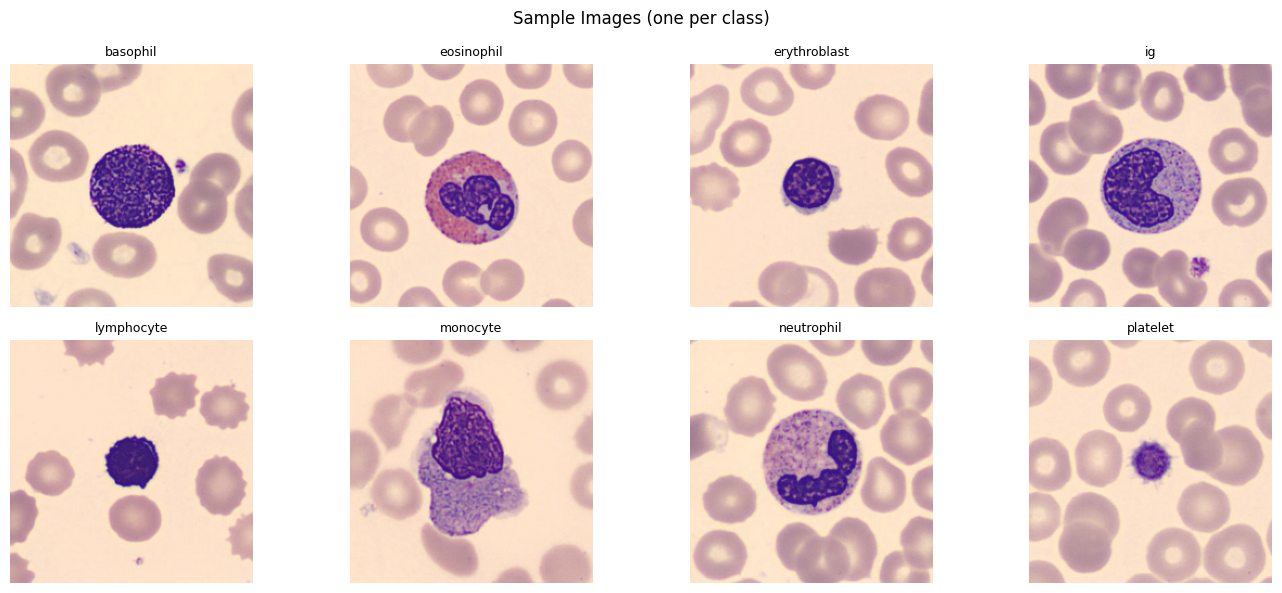

 Transforms ready!


In [6]:
# Task 1.3 — Transforms: resize, normalize, augment
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomVerticalFlip(0.3),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
val_test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
# Show one sample per class
fig, axes = plt.subplots(2, 4, figsize=(14,6))
fig.suptitle('Sample Images (one per class)')
for ax, cls in zip(axes.flat, CLASSES):
    p = df_all[df_all['label']==cls].iloc[0]['path']
    ax.imshow(Image.open(p).convert('RGB').resize((224,224)))
    ax.set_title(cls, fontsize=9); ax.axis('off')
plt.tight_layout(); plt.show()
print(' Transforms ready!')


## Task 1.4 — Train/Val/Test Split & DataLoaders

In [7]:
# Task 1.4 — Stratified 70/15/15 split
class BloodCellDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.c2i = {c:i for i,c in enumerate(CLASSES)}
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        r   = self.df.iloc[idx]
        img = Image.open(r['path']).convert('RGB')
        if self.transform: img = self.transform(img)
        return img, self.c2i[r['label']]
df_tr, df_tmp = train_test_split(
    df_all, test_size=0.30, stratify=df_all['label'], random_state=SEED)
df_val, df_te = train_test_split(
    df_tmp, test_size=0.50, stratify=df_tmp['label'], random_state=SEED)
print(f'Train:{len(df_tr)}  Val:{len(df_val)}  Test:{len(df_te)}')
train_ds = BloodCellDataset(df_tr,  train_transforms)
val_ds   = BloodCellDataset(df_val, val_test_transforms)
test_ds  = BloodCellDataset(df_te,  val_test_transforms)
# Weighted sampler for class imbalance
lc  = df_tr['label'].value_counts().sort_index()
cw  = 1.0 / torch.tensor([lc[c] for c in CLASSES], dtype=torch.float)
sw  = torch.tensor([cw[CLASSES.index(r)] for r in df_tr['label']])
sampler = WeightedRandomSampler(sw, len(sw), replacement=True)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                          sampler=sampler, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)
print(f' Loaders ready  Train:{len(train_loader)}  Val:{len(val_loader)}  Test:{len(test_loader)}')


Train:11964  Val:2564  Test:2564
 Loaders ready  Train:374  Val:81  Test:81


---
#  Task 2 — Custom CNNs (3 / 4 / 5 layers)

In [8]:
# Task 2.1 — Conv block + three CNN architectures
def conv_block(in_ch, out_ch, dropout=0.25):
    return nn.Sequential(
        nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
        nn.BatchNorm2d(out_ch),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(2, 2),
        nn.Dropout2d(dropout),
    )
class CustomCNN3(nn.Module):
    """3 conv layers — filters: 32→64→128"""
    def __init__(self, nc=8):
        super().__init__()
        self.features = nn.Sequential(
            conv_block(3, 32, 0.25),
            conv_block(32, 64, 0.25),
            conv_block(64, 128, 0.25),
        )
        self.pool = nn.AdaptiveAvgPool2d((4,4))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*4*4, 512), nn.ReLU(True), nn.Dropout(0.5),
            nn.Linear(512, nc)
        )
    def forward(self, x):
        return self.classifier(self.pool(self.features(x)))
class CustomCNN4(nn.Module):
    """4 conv layers — filters: 32→64→128→256"""
    def __init__(self, nc=8):
        super().__init__()
        self.features = nn.Sequential(
            conv_block(3, 32, 0.20),
            conv_block(32, 64, 0.20),
            conv_block(64, 128, 0.25),
            conv_block(128, 256, 0.25),
        )
        self.pool = nn.AdaptiveAvgPool2d((3,3))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256*3*3, 1024), nn.ReLU(True), nn.Dropout(0.5),
            nn.Linear(1024, 512),     nn.ReLU(True), nn.Dropout(0.4),
            nn.Linear(512, nc)
        )
    def forward(self, x):
        return self.classifier(self.pool(self.features(x)))
class CustomCNN5(nn.Module):
    """5 conv layers — filters: 32→64→128→256→512"""
    def __init__(self, nc=8):
        super().__init__()
        self.features = nn.Sequential(
            conv_block(3, 32, 0.15),
            conv_block(32, 64, 0.15),
            conv_block(64, 128, 0.20),
            conv_block(128, 256, 0.25),
            conv_block(256, 512, 0.25),
        )
        self.pool = nn.AdaptiveAvgPool2d((2,2))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512*2*2, 1024), nn.ReLU(True), nn.Dropout(0.5),
            nn.Linear(1024, 256),     nn.ReLU(True), nn.Dropout(0.4),
            nn.Linear(256, nc)
        )
    def forward(self, x):
        return self.classifier(self.pool(self.features(x)))
for M in [CustomCNN3, CustomCNN4, CustomCNN5]:
    m = M(NUM_CLASSES)
    p = sum(x.numel() for x in m.parameters() if x.requires_grad)
    print(f'{M.__name__}: {p:,} trainable params')
print(' Architectures ready!')


CustomCNN3: 1,146,664 trainable params
CustomCNN4: 3,278,120 trainable params
CustomCNN5: 3,932,200 trainable params
 Architectures ready!


## Task 2.2 — Training Utilities

In [9]:
# Task 2.2 — train loop + eval + plot
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    ls, ok, tot = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, labels)
        loss.backward(); optimizer.step()
        ls  += loss.item() * imgs.size(0)
        ok  += (out.argmax(1) == labels).sum().item()
        tot += imgs.size(0)
    return ls/tot, ok/tot
@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    ls, ok, tot = 0.0, 0, 0
    all_p, all_l = [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        out  = model(imgs)
        ls  += criterion(out, labels).item() * imgs.size(0)
        p    = out.argmax(1)
        ok  += (p == labels).sum().item(); tot += imgs.size(0)
        all_p.extend(p.cpu().numpy())
        all_l.extend(labels.cpu().numpy())
    return ls/tot, ok/tot, all_p, all_l
def train_model(model, name, epochs=30, lr=1e-3):
    model = model.to(DEVICE)
    crit  = nn.CrossEntropyLoss(label_smoothing=0.1)
    opt   = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    sch   = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    best_acc, patience = 0.0, 0
    hist = {'tl':[],'vl':[],'ta':[],'va':[]}
    for ep in range(1, epochs+1):
        tl, ta     = train_epoch(model, train_loader, crit, opt)
        vl, va,_,_ = eval_epoch(model, val_loader, crit)
        sch.step()
        for k,v in zip(['tl','vl','ta','va'],[tl,vl,ta,va]):
            hist[k].append(v)
        if va > best_acc:
            best_acc = va
            torch.save(model.state_dict(), f'/content/{name}_best.pth')
            patience = 0
        else:
            patience += 1
        if ep % 5 == 0 or ep == 1:
            print(f'Ep{ep:3d} | TrLoss:{tl:.4f} TrAcc:{ta:.4f} | VaLoss:{vl:.4f} VaAcc:{va:.4f}')
        if patience >= 8:
            print(f' Early stop at epoch {ep}')
            break
    model.load_state_dict(torch.load(f'/content/{name}_best.pth', map_location=DEVICE))
    print(f' Best val accuracy: {best_acc:.4f}')
    return hist
def plot_curves(hist, name):
    fig, (a1,a2) = plt.subplots(1, 2, figsize=(12,4))
    a1.plot(hist['tl'], label='Train'); a1.plot(hist['vl'], label='Val')
    a1.set_title(f'{name} — Loss'); a1.legend(); a1.grid(True)
    a2.plot(hist['ta'], label='Train'); a2.plot(hist['va'], label='Val')
    a2.set_title(f'{name} — Accuracy'); a2.legend(); a2.grid(True)
    plt.tight_layout(); plt.show()
def full_eval(model, name):
    _, acc, preds, labels = eval_epoch(model, test_loader, nn.CrossEntropyLoss())
    p = precision_score(labels, preds, average='macro', zero_division=0)
    r = recall_score(labels, preds, average='macro', zero_division=0)
    f = f1_score(labels, preds, average='macro', zero_division=0)
    print(f'\n {name}  Acc:{acc:.4f}  Prec:{p:.4f}  Rec:{r:.4f}  F1:{f:.4f}')
    print(classification_report(labels, preds, target_names=CLASSES, zero_division=0))
    cm = confusion_matrix(labels, preds)
    fig, ax = plt.subplots(figsize=(9,7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASSES, yticklabels=CLASSES, ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(f'{name} — Confusion Matrix')
    plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()
    return {'accuracy':acc,'precision':p,'recall':r,'f1':f}
print(' Training utilities ready!')


 Training utilities ready!


## Train CNN3 (3 layers)

 Training CNN3...
Ep  1 | TrLoss:1.6084 TrAcc:0.4232 | VaLoss:1.3529 VaAcc:0.5511
Ep  5 | TrLoss:1.1605 TrAcc:0.6956 | VaLoss:0.9706 VaAcc:0.7621
Ep 10 | TrLoss:0.9846 TrAcc:0.7960 | VaLoss:0.7510 VaAcc:0.8998
Ep 15 | TrLoss:0.8884 TrAcc:0.8517 | VaLoss:0.7043 VaAcc:0.9158
Ep 20 | TrLoss:0.8259 TrAcc:0.8780 | VaLoss:0.6637 VaAcc:0.9395
Ep 25 | TrLoss:0.7924 TrAcc:0.8940 | VaLoss:0.6465 VaAcc:0.9442
Ep 30 | TrLoss:0.7871 TrAcc:0.8996 | VaLoss:0.6412 VaAcc:0.9438
 Best val accuracy: 0.9485


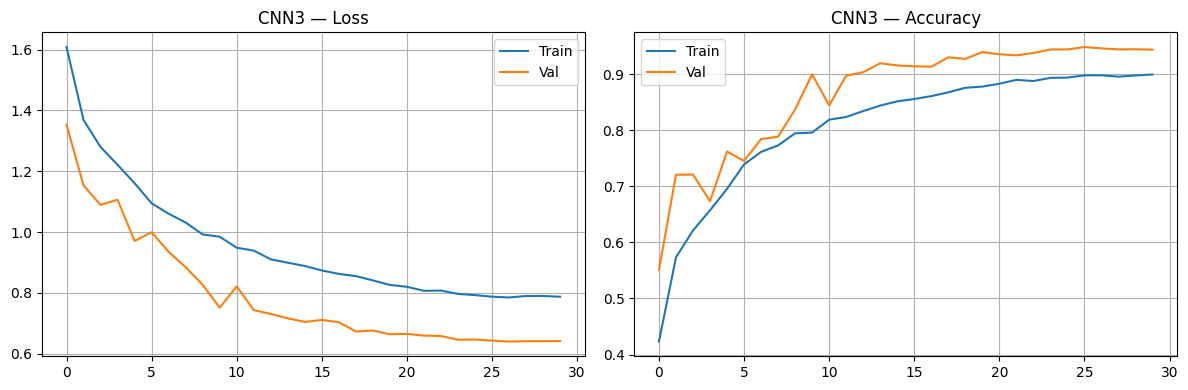


 CNN3  Acc:0.9407  Prec:0.9358  Rec:0.9449  F1:0.9388
              precision    recall  f1-score   support

    basophil       0.86      0.99      0.92       183
  eosinophil       1.00      1.00      1.00       467
erythroblast       0.96      0.94      0.95       233
          ig       0.93      0.79      0.85       434
  lymphocyte       0.95      0.97      0.96       182
    monocyte       0.88      0.92      0.90       213
  neutrophil       0.90      0.97      0.94       500
    platelet       1.00      0.99      0.99       352

    accuracy                           0.94      2564
   macro avg       0.94      0.94      0.94      2564
weighted avg       0.94      0.94      0.94      2564



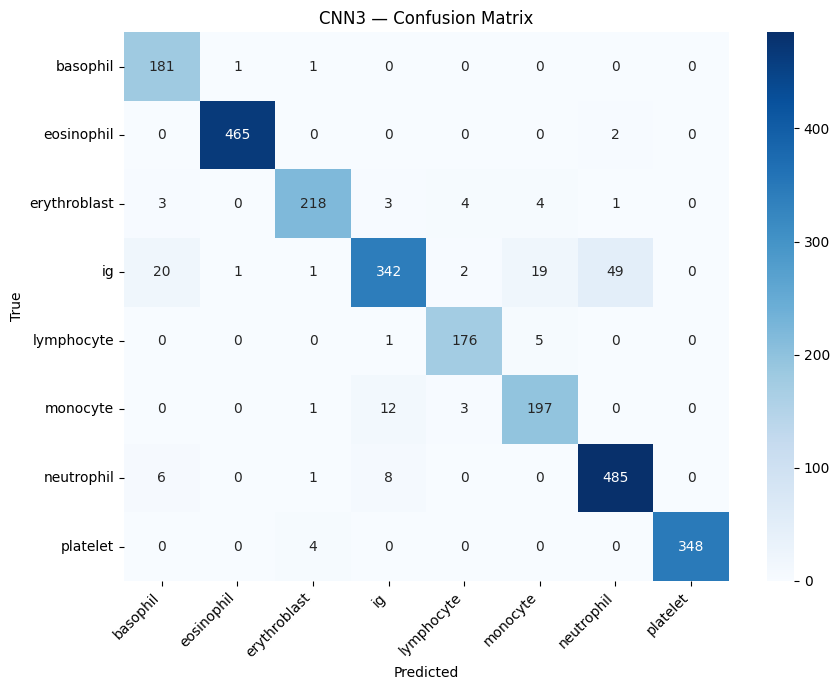

In [12]:
set_seed()
model_cnn3 = CustomCNN3(NUM_CLASSES)
print(' Training CNN3...')
hist3 = train_model(model_cnn3, 'cnn3', epochs=30, lr=1e-3)
plot_curves(hist3, 'CNN3')
res3  = full_eval(model_cnn3, 'CNN3')

## Train CNN4 (4 layers)

 Training CNN4...
Ep  1 | TrLoss:1.6972 TrAcc:0.3606 | VaLoss:1.5427 VaAcc:0.3651
Ep  5 | TrLoss:1.2161 TrAcc:0.6423 | VaLoss:1.0228 VaAcc:0.6958
Ep 10 | TrLoss:0.9512 TrAcc:0.7910 | VaLoss:0.8963 VaAcc:0.7952
Ep 15 | TrLoss:0.8158 TrAcc:0.8539 | VaLoss:0.7720 VaAcc:0.8705
Ep 20 | TrLoss:0.7353 TrAcc:0.8940 | VaLoss:0.6693 VaAcc:0.9236
Ep 25 | TrLoss:0.6863 TrAcc:0.9102 | VaLoss:0.6138 VaAcc:0.9442
Ep 30 | TrLoss:0.6699 TrAcc:0.9179 | VaLoss:0.6109 VaAcc:0.9481
 Best val accuracy: 0.9481


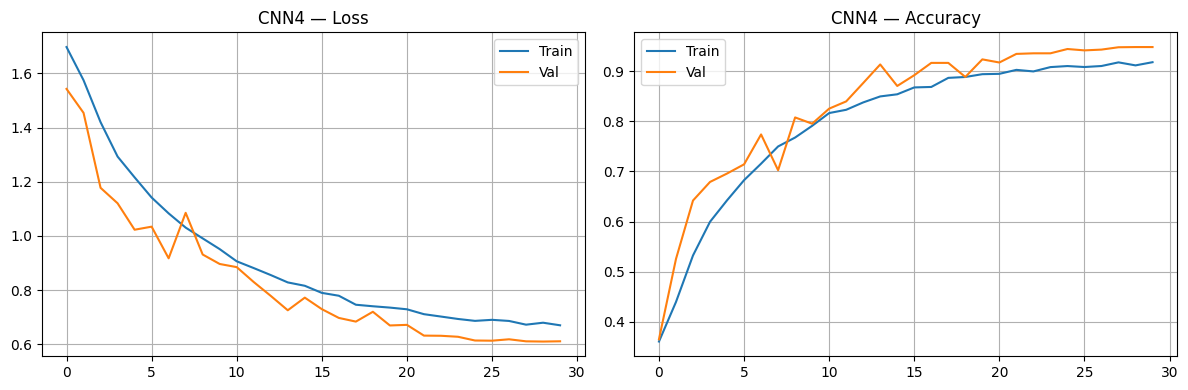


 CNN4  Acc:0.9470  Prec:0.9402  Rec:0.9480  F1:0.9427
              precision    recall  f1-score   support

    basophil       0.86      0.99      0.92       183
  eosinophil       1.00      1.00      1.00       467
erythroblast       0.97      0.93      0.95       233
          ig       0.94      0.82      0.88       434
  lymphocyte       0.92      0.97      0.94       182
    monocyte       0.91      0.91      0.91       213
  neutrophil       0.92      0.98      0.95       500
    platelet       1.00      0.99      1.00       352

    accuracy                           0.95      2564
   macro avg       0.94      0.95      0.94      2564
weighted avg       0.95      0.95      0.95      2564



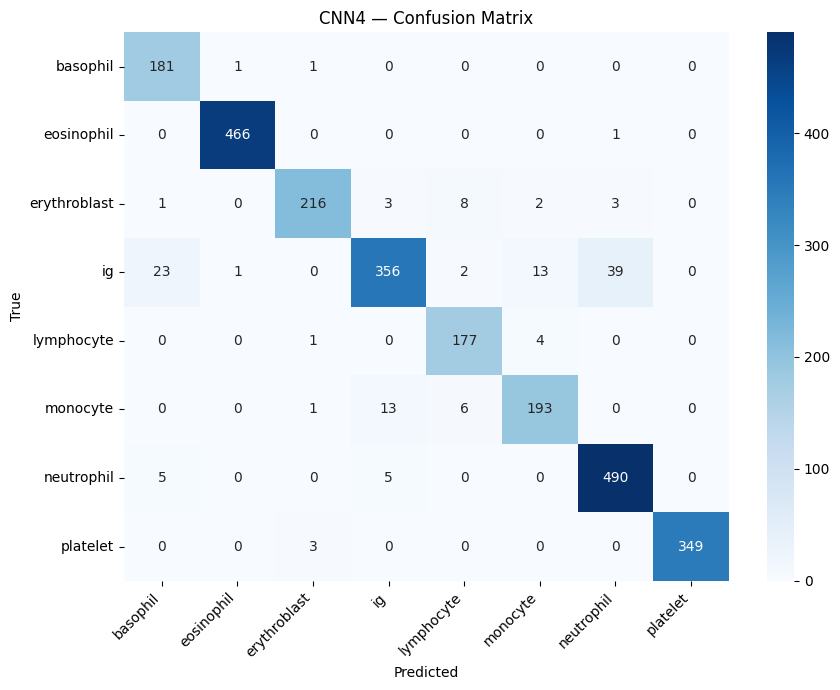

In [14]:
set_seed()
model_cnn4 = CustomCNN4(NUM_CLASSES)
print(' Training CNN4...')
hist4 = train_model(model_cnn4, 'cnn4', epochs=30, lr=1e-3)
plot_curves(hist4, 'CNN4')
res4  = full_eval(model_cnn4, 'CNN4')

## Train CNN5 (5 layers)

Training CNN5...
Ep  1 | TrLoss:1.9240 TrAcc:0.2312 | VaLoss:1.4433 VaAcc:0.4715
Ep  5 | TrLoss:1.0602 TrAcc:0.7370 | VaLoss:0.8134 VaAcc:0.8487
Ep 10 | TrLoss:0.8554 TrAcc:0.8465 | VaLoss:0.7643 VaAcc:0.8662
Ep 15 | TrLoss:0.7336 TrAcc:0.8988 | VaLoss:0.6052 VaAcc:0.9477
Ep 20 | TrLoss:0.6719 TrAcc:0.9235 | VaLoss:0.6065 VaAcc:0.9368
Ep 25 | TrLoss:0.6263 TrAcc:0.9435 | VaLoss:0.5431 VaAcc:0.9680
Ep 30 | TrLoss:0.6185 TrAcc:0.9468 | VaLoss:0.5406 VaAcc:0.9704
 Best val accuracy: 0.9715


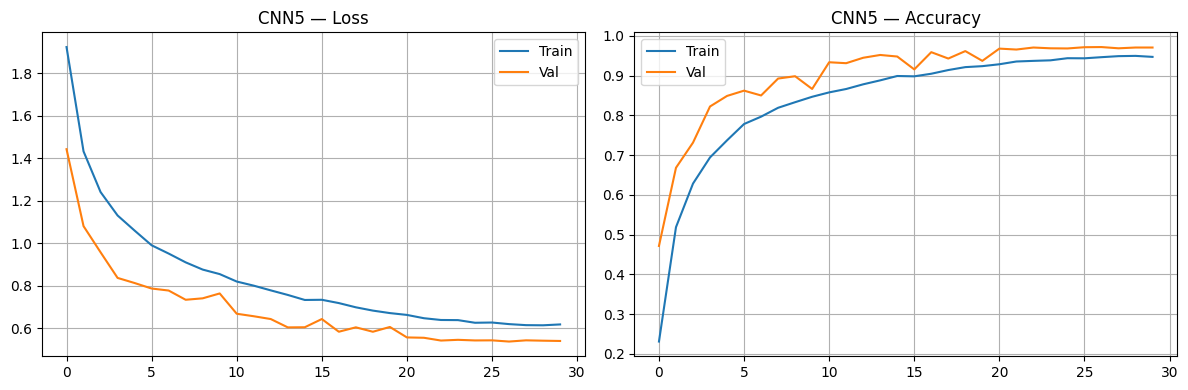


 CNN5  Acc:0.9750  Prec:0.9703  Rec:0.9766  F1:0.9733
              precision    recall  f1-score   support

    basophil       0.96      1.00      0.98       183
  eosinophil       1.00      1.00      1.00       467
erythroblast       0.99      0.98      0.98       233
          ig       0.96      0.94      0.95       434
  lymphocyte       0.95      0.99      0.97       182
    monocyte       0.93      0.93      0.93       213
  neutrophil       0.98      0.97      0.97       500
    platelet       1.00      1.00      1.00       352

    accuracy                           0.98      2564
   macro avg       0.97      0.98      0.97      2564
weighted avg       0.98      0.98      0.98      2564



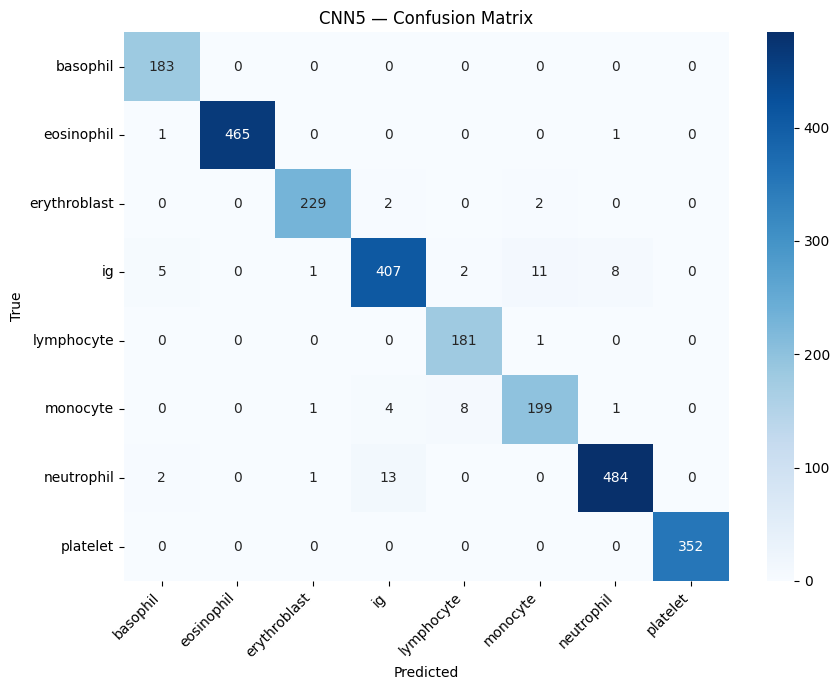

In [15]:
set_seed()
model_cnn5 = CustomCNN5(NUM_CLASSES)
print('Training CNN5...')
hist5 = train_model(model_cnn5, 'cnn5', epochs=30, lr=1e-3)
plot_curves(hist5, 'CNN5')
res5  = full_eval(model_cnn5, 'CNN5')

## Custom CNN Results Comparison

In [16]:
cnn_df = pd.DataFrame({'CNN3':res3,'CNN4':res4,'CNN5':res5}).T.round(4)
print('\n Custom CNN Comparison:')
print(cnn_df.to_string())
best_cnn_name  = cnn_df['f1'].idxmax()
best_cnn_model = {'CNN3':model_cnn3,'CNN4':model_cnn4,'CNN5':model_cnn5}[best_cnn_name]
print(f'\n Best custom CNN: {best_cnn_name}')



 Custom CNN Comparison:
      accuracy  precision  recall      f1
CNN3    0.9407     0.9358  0.9449  0.9388
CNN4    0.9470     0.9402  0.9480  0.9427
CNN5    0.9750     0.9703  0.9766  0.9733

 Best custom CNN: CNN5


---
#  Task 3 — Transfer Learning

In [17]:
# Task 3 — MobileNetV2, SqueezeNet, ResNet18
def build_mobilenet(nc=8):
    m = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
    for p in m.parameters(): p.requires_grad = False
    for p in m.features[-3:].parameters(): p.requires_grad = True
    inf = m.classifier[1].in_features
    m.classifier = nn.Sequential(
        nn.Dropout(0.3), nn.Linear(inf, 512), nn.ReLU(True),
        nn.Dropout(0.3), nn.Linear(512, nc)
    )
    return m, 'MobileNetV2'
def build_squeezenet(nc=8):
    m = models.squeezenet1_1(weights=models.SqueezeNet1_1_Weights.DEFAULT)
    for p in m.features.parameters(): p.requires_grad = False
    for p in m.features[-3:].parameters(): p.requires_grad = True
    m.classifier[1] = nn.Conv2d(512, nc, kernel_size=1)
    m.num_classes = nc
    return m, 'SqueezeNet'
def build_resnet(nc=8):
    m = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    for p in m.parameters(): p.requires_grad = False
    for p in m.layer4.parameters(): p.requires_grad = True
    inf = m.fc.in_features
    m.fc = nn.Sequential(
        nn.Linear(inf, 512), nn.ReLU(True),
        nn.Dropout(0.4), nn.Linear(512, nc)
    )
    return m, 'ResNet18'
for builder in [build_mobilenet, build_squeezenet, build_resnet]:
    m, name = builder(NUM_CLASSES)
    tot = sum(p.numel() for p in m.parameters())
    trn = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f'{name:15s}: {trn:>10,} trainable / {tot:>12,} total')
print(' Pretrained models ready!')


Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 97.4MB/s]


MobileNetV2    :  1,866,056 trainable /    2,883,848 total
Downloading: "https://download.pytorch.org/models/squeezenet1_1-b8a52dc0.pth" to /root/.cache/torch/hub/checkpoints/squeezenet1_1-b8a52dc0.pth


100%|██████████| 4.73M/4.73M [00:00<00:00, 61.2MB/s]

SqueezeNet     :    501,304 trainable /      726,600 total


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 165MB/s]


ResNet18       :  8,660,488 trainable /   11,443,272 total
 Pretrained models ready!


## Train MobileNetV2

 Training MobileNetV2...
Ep  1 | TrLoss:0.8018 TrAcc:0.8658 | VaLoss:0.6274 VaAcc:0.9380
Ep  5 | TrLoss:0.5845 TrAcc:0.9560 | VaLoss:0.5574 VaAcc:0.9641
Ep 10 | TrLoss:0.5548 TrAcc:0.9687 | VaLoss:0.5369 VaAcc:0.9704
Ep 15 | TrLoss:0.5265 TrAcc:0.9784 | VaLoss:0.5234 VaAcc:0.9754
 Early stop at epoch 15
 Best val accuracy: 0.9754


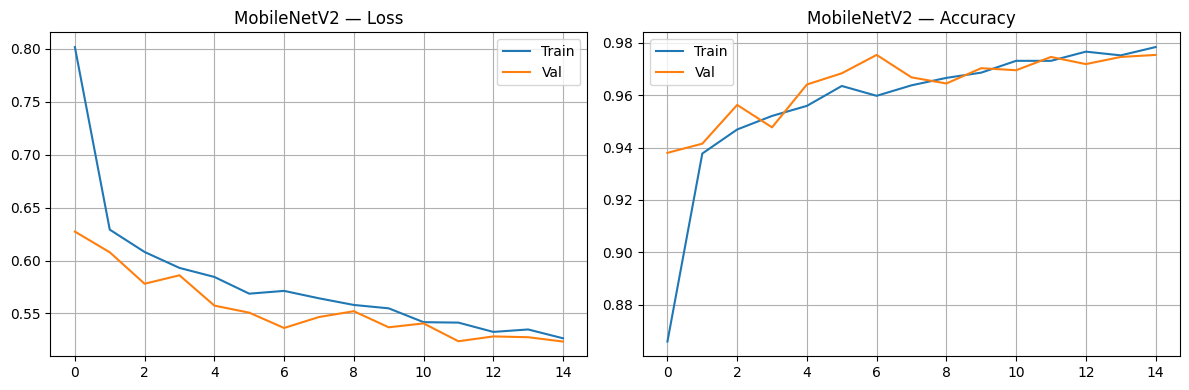


 MobileNetV2  Acc:0.9692  Prec:0.9696  Rec:0.9696  F1:0.9694
              precision    recall  f1-score   support

    basophil       0.97      0.99      0.98       183
  eosinophil       1.00      1.00      1.00       467
erythroblast       0.98      0.97      0.98       233
          ig       0.91      0.94      0.93       434
  lymphocyte       0.96      0.99      0.98       182
    monocyte       0.97      0.92      0.94       213
  neutrophil       0.97      0.96      0.96       500
    platelet       1.00      1.00      1.00       352

    accuracy                           0.97      2564
   macro avg       0.97      0.97      0.97      2564
weighted avg       0.97      0.97      0.97      2564



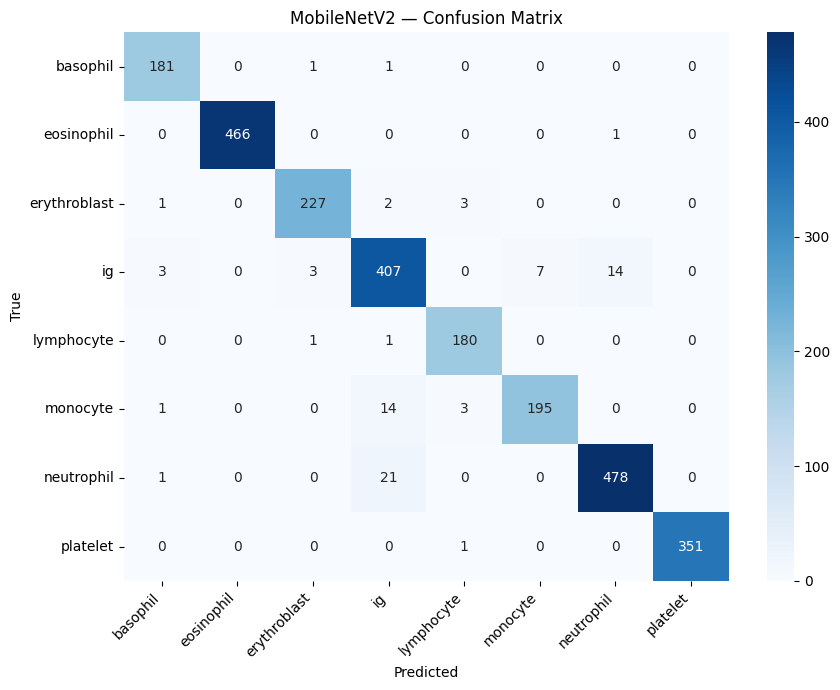

In [18]:
set_seed()
model_mn, mn_name = build_mobilenet(NUM_CLASSES)
print(f' Training {mn_name}...')
hist_mn = train_model(model_mn, 'mobilenet', epochs=20, lr=5e-4)
plot_curves(hist_mn, mn_name)
res_mn = full_eval(model_mn, mn_name)


## Train SqueezeNet

 Training SqueezeNet...
Ep  1 | TrLoss:0.9420 TrAcc:0.8022 | VaLoss:0.7288 VaAcc:0.8963
Ep  5 | TrLoss:0.5905 TrAcc:0.9586 | VaLoss:0.5916 VaAcc:0.9563
Ep 10 | TrLoss:0.5494 TrAcc:0.9735 | VaLoss:0.5573 VaAcc:0.9668
Ep 15 | TrLoss:0.5244 TrAcc:0.9829 | VaLoss:0.5365 VaAcc:0.9774
Ep 20 | TrLoss:0.5153 TrAcc:0.9853 | VaLoss:0.5294 VaAcc:0.9805
 Best val accuracy: 0.9805


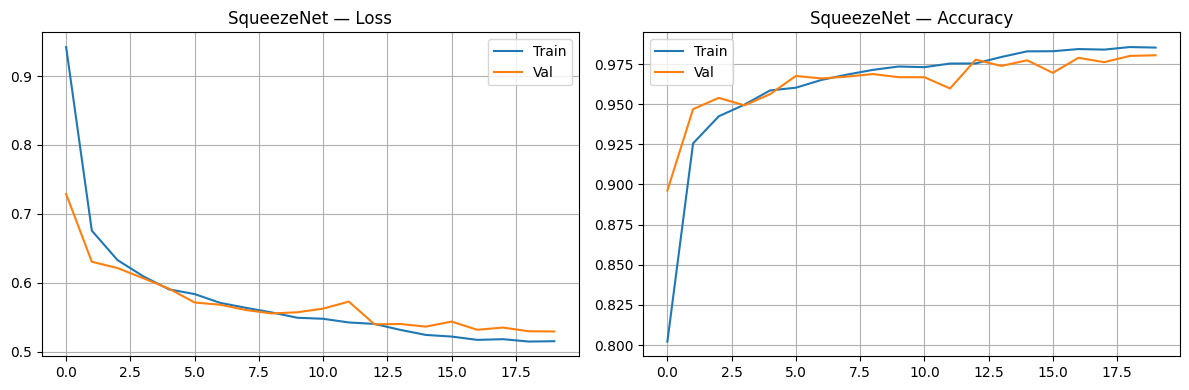


 SqueezeNet  Acc:0.9766  Prec:0.9756  Rec:0.9766  F1:0.9761
              precision    recall  f1-score   support

    basophil       0.99      0.98      0.98       183
  eosinophil       1.00      0.99      1.00       467
erythroblast       0.98      0.99      0.99       233
          ig       0.94      0.94      0.94       434
  lymphocyte       0.97      0.98      0.98       182
    monocyte       0.94      0.95      0.95       213
  neutrophil       0.98      0.98      0.98       500
    platelet       1.00      1.00      1.00       352

    accuracy                           0.98      2564
   macro avg       0.98      0.98      0.98      2564
weighted avg       0.98      0.98      0.98      2564



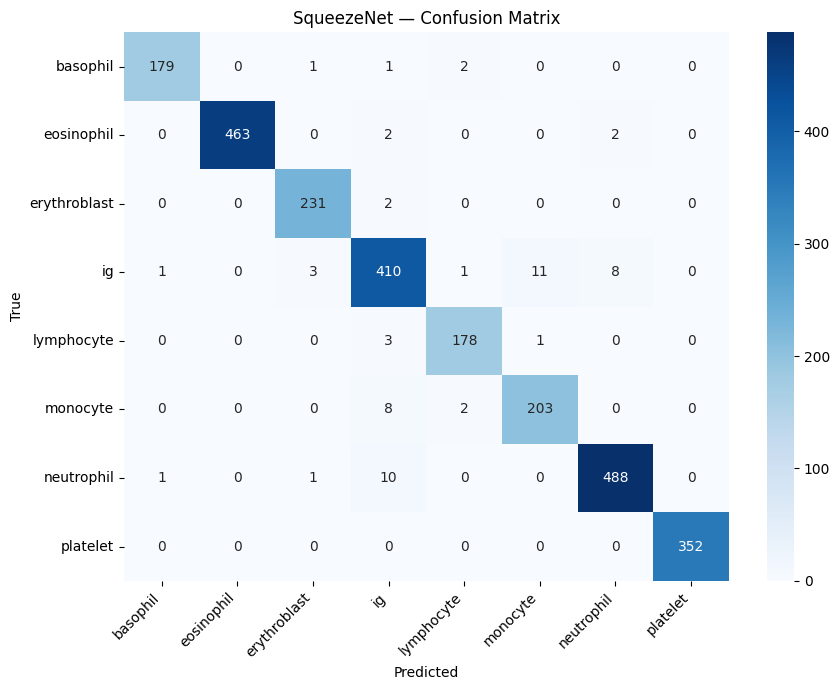

In [19]:
set_seed()
model_sn, sn_name = build_squeezenet(NUM_CLASSES)
print(f' Training {sn_name}...')
hist_sn = train_model(model_sn, 'squeezenet', epochs=20, lr=5e-4)
plot_curves(hist_sn, sn_name)
res_sn = full_eval(model_sn, sn_name)


## Train ResNet18

 Training ResNet18...
Ep  1 | TrLoss:0.7017 TrAcc:0.9107 | VaLoss:0.5763 VaAcc:0.9594
Ep  5 | TrLoss:0.5550 TrAcc:0.9677 | VaLoss:0.5293 VaAcc:0.9743
Ep 10 | TrLoss:0.5228 TrAcc:0.9814 | VaLoss:0.5237 VaAcc:0.9789
Ep 15 | TrLoss:0.4962 TrAcc:0.9914 | VaLoss:0.5156 VaAcc:0.9785
Ep 20 | TrLoss:0.4887 TrAcc:0.9936 | VaLoss:0.5076 VaAcc:0.9832
 Best val accuracy: 0.9844


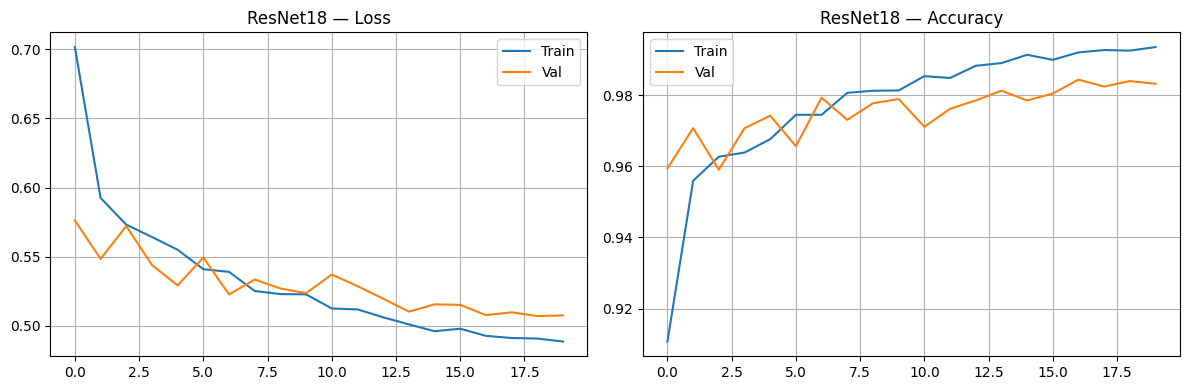


 ResNet18  Acc:0.9852  Prec:0.9837  Rec:0.9854  F1:0.9846
              precision    recall  f1-score   support

    basophil       0.98      1.00      0.99       183
  eosinophil       1.00      1.00      1.00       467
erythroblast       0.99      1.00      0.99       233
          ig       0.98      0.95      0.97       434
  lymphocyte       0.98      0.99      0.98       182
    monocyte       0.97      0.96      0.96       213
  neutrophil       0.98      0.99      0.98       500
    platelet       1.00      1.00      1.00       352

    accuracy                           0.99      2564
   macro avg       0.98      0.99      0.98      2564
weighted avg       0.99      0.99      0.99      2564



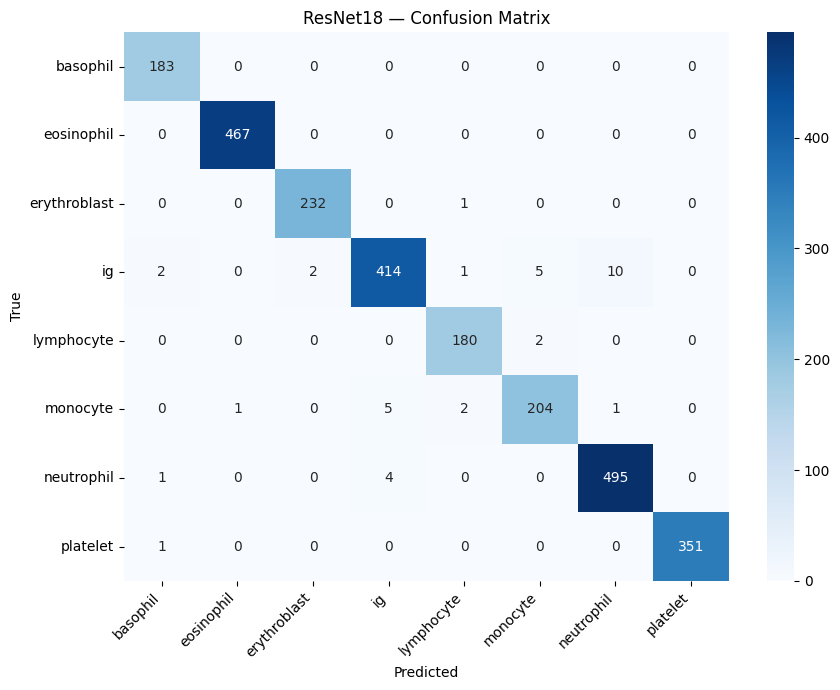

In [20]:
set_seed()
model_rn, rn_name = build_resnet(NUM_CLASSES)
print(f' Training {rn_name}...')
hist_rn = train_model(model_rn, 'resnet18', epochs=20, lr=5e-4)
plot_curves(hist_rn, rn_name)
res_rn = full_eval(model_rn, rn_name)

## All Models Final Comparison

 FINAL RESULTS (sorted by F1 score)
             accuracy  precision  recall      f1
ResNet18       0.9852     0.9837  0.9854  0.9846
SqueezeNet     0.9766     0.9756  0.9766  0.9761
CNN5           0.9750     0.9703  0.9766  0.9733
MobileNetV2    0.9692     0.9696  0.9696  0.9694
CNN4           0.9470     0.9402  0.9480  0.9427
CNN3           0.9407     0.9358  0.9449  0.9388


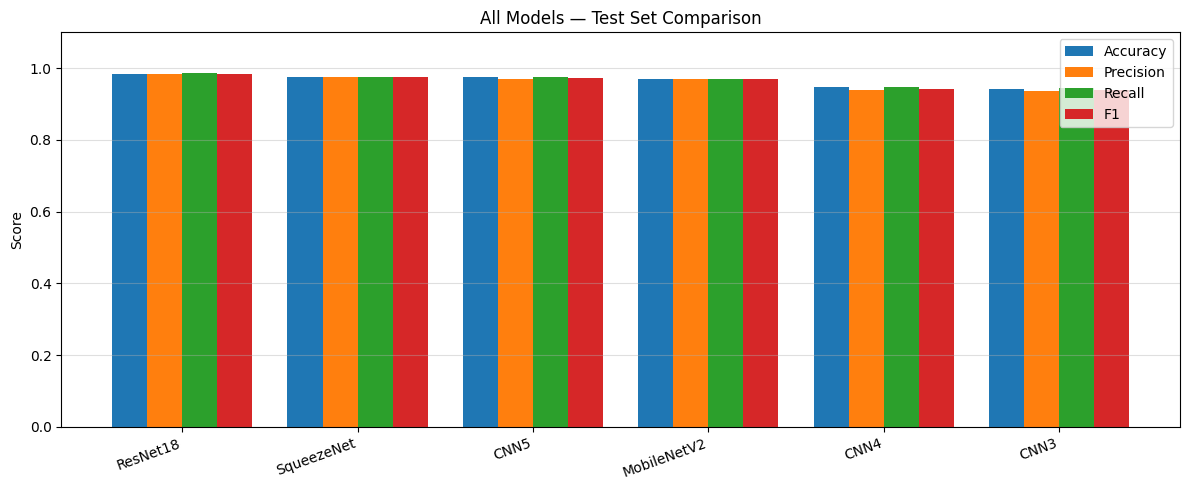

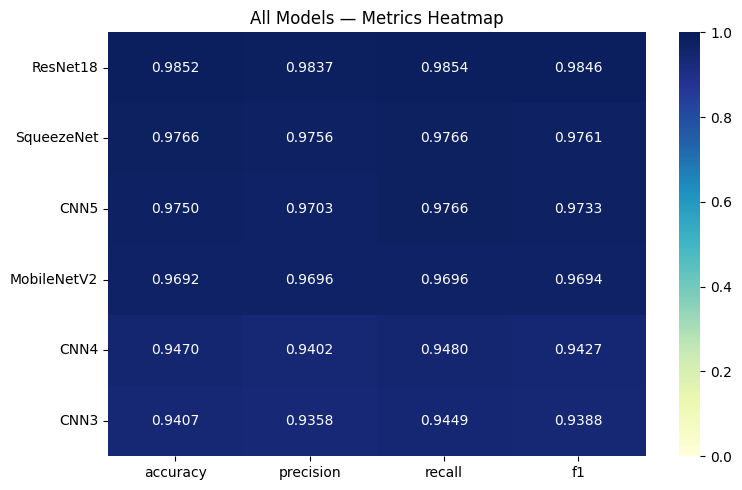


 Best custom CNN   : CNN5
Best pretrained   : ResNet18


In [21]:
all_res = pd.DataFrame({
    'CNN3':res3, 'CNN4':res4, 'CNN5':res5,
    mn_name:res_mn, sn_name:res_sn, rn_name:res_rn
}).T.round(4).sort_values('f1', ascending=False)
print('='*55)
print(' FINAL RESULTS (sorted by F1 score)')
print('='*55)
print(all_res.to_string())
# Bar chart
fig, ax = plt.subplots(figsize=(12,5))
x = np.arange(len(all_res)); w = 0.2
for i, metric in enumerate(['accuracy','precision','recall','f1']):
    ax.bar(x+i*w, all_res[metric], w, label=metric.capitalize())
ax.set_xticks(x+w*1.5)
ax.set_xticklabels(all_res.index, rotation=20, ha='right')
ax.set_ylabel('Score'); ax.set_title('All Models — Test Set Comparison')
ax.legend(); ax.set_ylim(0, 1.1); ax.grid(axis='y', alpha=0.4)
plt.tight_layout(); plt.show()
# Heatmap
fig, ax = plt.subplots(figsize=(8,5))
sns.heatmap(all_res.astype(float), annot=True, fmt='.4f',
            cmap='YlGnBu', ax=ax, vmin=0, vmax=1)
ax.set_title('All Models — Metrics Heatmap')
plt.tight_layout(); plt.show()
# Best pretrained
pt_df = pd.DataFrame({mn_name:res_mn, sn_name:res_sn, rn_name:res_rn}).T
best_pt_label = pt_df['f1'].idxmax()
best_pt_model = {mn_name:model_mn, sn_name:model_sn, rn_name:model_rn}[best_pt_label]
print(f'\n Best custom CNN   : {best_cnn_name}')
print(f'Best pretrained   : {best_pt_label}')
